# **7. Hyperparameter Tuning**

This notebook applies hyperparameter tuning to the best-performing variants of the Logistic Regression, Random Forest, and XGBoost classifiers identified during the class imbalance handling experiments. GridSearchCV is employed to systematically evaluate combinations of model hyperparameters using stratified cross-validation. The objective is to optimize predictive performance while maintaining robust generalization on unseen data.

## **Library Imports**

The required libraries are imported to support data manipulation, hyperparameter optimization, cross-validation, model development, and performance evaluation.

In [16]:
# Import required libraries

import pandas as pd                      # Data manipulation and analysis
import numpy as np                       # Numerical computations
import matplotlib.pyplot as plt      # Data visualization
import seaborn as sns                # Statistical data visualization
import joblib                            # Saving and loading trained models

# Import model selection tools
from sklearn.model_selection import (
    GridSearchCV,                        # Exhaustive hyperparameter search
    StratifiedKFold                      # Stratified cross-validation
)

# Import preprocessing tools
from sklearn.preprocessing import StandardScaler       # Feature standardization

# Import imbalance handling tools
from imblearn.combine import SMOTEENN                   # Hybrid resampling technique
from imblearn.pipeline import Pipeline                  # Pipeline supporting resampling

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

### **Data Ingestion**

The previously prepared training and testing datasets are loaded for hyperparameter tuning. Scaled datasets are used for Logistic Regression, while the original unscaled datasets are retained for Random Forest and XGBoost because tree-based algorithms are not affected by differences in feature scales.

In [7]:
# Load the original datasets
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

# Load the scaled datasets
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")

# Load the target variables
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Display dataset dimensions
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (3392, 15)
X_test shape : (848, 15)
X_train_scaled shape: (3392, 15)
X_test_scaled shape : (848, 15)
y_train shape: (3392,)
y_test shape : (848,)


The original training and testing datasets were successfully loaded for hyperparameter tuning. The scaled datasets will be used for Logistic Regression, whereas the original unscaled datasets will be used for Random Forest and XGBoost. Class imbalance handling will be incorporated within the cross-validation pipelines to ensure unbiased model optimization.

### **Cross-Validation Strategy**


A stratified five-fold cross-validation strategy is adopted to preserve the original class distribution within each fold during hyperparameter optimization. This approach provides a reliable estimate of model performance while reducing the likelihood of overfitting. The `scale_pos_weight` parameter required for XGBoost is also calculated from the class distribution of the training dataset.t.

In [8]:
# Calculate the scale_pos_weight value
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(cv)

scale_pos_weight: 5.59
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


The value of `scale_pos_weight` was calculated to compensate for class imbalance during XGBoost training. A five-fold stratified cross-validation strategy was defined to ensure that each fold retained a representative distribution of the target classes throughout the hyperparameter search.

## **Logistic Regression Hyperparameter Tuning**

Hyperparameter tuning is performed to identify the optimal configuration of the Logistic Regression classifier. A pipeline is used to standardize the predictor variables, apply SMOTE-ENN within each cross-validation fold, and train the classifier. This approach prevents data leakage while allowing GridSearchCV to evaluate different model configurations using stratified five-fold cross-validation.

### **Hyperparameter Grid**

The hyperparameter search space includes different regularization strengths, penalty functions, and optimization algorithms. The parameter names are prefixed with `model__` because the Logistic Regression classifier is included as the final step of the pipeline.

In [10]:
# Define the Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("resampler", SMOTEENN(random_state=42)),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Define the hyperparameter grid using the current parameter syntax
lr_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.0, 1.0],
    "model__solver": ["saga"]
}

# Initialize GridSearchCV
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# Perform hyperparameter tuning
lr_grid.fit(X_train, y_train)

# Display the best results
print("Best Parameters:", lr_grid.best_params_)
print(f"Best Cross-Validation ROC-AUC: {lr_grid.best_score_:.3f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'model__C': 0.01, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}
Best Cross-Validation ROC-AUC: 0.732


**Best Hyperparameters**

GridSearchCV identified the optimal Logistic Regression configuration as an inverse regularization strength (`C`) of 0.01, an L2 penalty, and the `saga` optimization solver. The best model achieved a mean cross-validation ROC-AUC score of 0.732, indicating good discriminative performance across the five validation folds.

### **Model Evaluation**

The optimized Logistic Regression pipeline is evaluated on the independent testing dataset to determine whether hyperparameter tuning improves predictive performance compared with the untuned SMOTE-ENN Logistic Regression model.

In [11]:
# Retrieve the best Logistic Regression pipeline
best_lr_model = lr_grid.best_estimator_

# Generate predicted class labels
y_pred_lr_tuned = best_lr_model.predict(X_test)

# Generate predicted probabilities for the positive class
y_pred_proba_lr_tuned = best_lr_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The tuned Logistic Regression pipeline successfully generated predicted class labels and class probabilities for the testing dataset. These outputs are used to evaluate the effect of hyperparameter optimization on predictive performance.

### **Performance Metrics**

The tuned Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics are compared with those of the untuned SMOTE-ENN Logistic Regression model to determine whether hyperparameter tuning produced meaningful improvements.

In [12]:
# Calculate evaluation metrics
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
precision_lr_tuned = precision_score(y_test, y_pred_lr_tuned)
recall_lr_tuned = recall_score(y_test, y_pred_lr_tuned)
f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned)
roc_auc_lr_tuned = roc_auc_score(y_test, y_pred_proba_lr_tuned)

# Create a summary table
lr_tuned_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_lr_tuned, 3),
        round(precision_lr_tuned, 3),
        round(recall_lr_tuned, 3),
        round(f1_lr_tuned, 3),
        round(roc_auc_lr_tuned, 3)
    ]
})

lr_tuned_metrics

,Metric,Value
0,Accuracy,0.546
1,Precision,0.224
2,Recall,0.806
3,F1-score,0.351
4,ROC-AUC,0.695


The tuned Logistic Regression model achieved an accuracy of 0.546, precision of 0.224, recall of 0.806, F1-score of 0.351, and ROC-AUC of 0.695 on the testing dataset. Compared with the untuned SMOTE-ENN Logistic Regression model, hyperparameter tuning resulted in improvements in precision, recall, F1-score, and ROC-AUC, while accuracy decreased only marginally.

The most notable improvement was observed in recall, which increased from 0.713 to 0.806, indicating that the tuned model correctly identified a substantially greater proportion of participants who developed coronary heart disease. The simultaneous improvement in F1-score and ROC-AUC further demonstrates that hyperparameter optimization enhanced the model's balance between minority class detection and overall discriminative performance. These findings suggest that the tuned Logistic Regression model provides superior predictive performance for this imbalanced classification task.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes of the tuned Logistic Regression model by comparing the predicted class labels with the actual class labels. It provides detailed insight into the numbers of true positives, true negatives, false positives, and false negatives, thereby illustrating the model's ability to correctly identify participants who developed coronary heart disease.

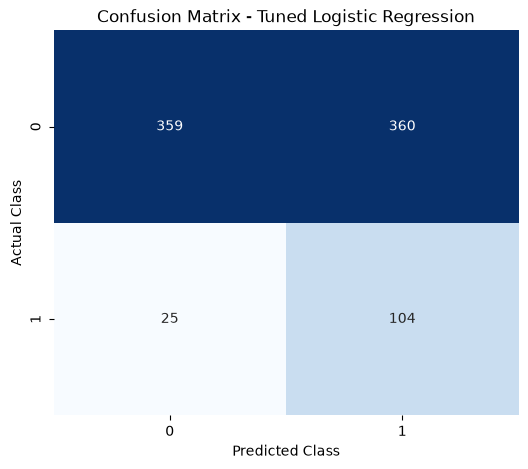

In [17]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr_tuned)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Tuned Logistic Regression")

# Display the plot
plt.show()

The confusion matrix demonstrates that hyperparameter tuning further improved the Logistic Regression model's ability to identify participants who developed coronary heart disease. Compared with the untuned SMOTE-ENN Logistic Regression model, the number of true positive predictions increased from 92 to 104, while false negatives decreased from 37 to 25, indicating a substantial improvement in minority class detection.

These improvements were accompanied by a slight increase in false positive predictions, which rose from 345 to 360, resulting in fewer correctly classified negative cases. Nevertheless, the reduction in false negatives and the increase in true positive predictions contributed to higher recall, F1-score, and ROC-AUC values. Overall, hyperparameter tuning enhanced the Logistic Regression model's sensitivity to coronary heart disease cases while maintaining competitive overall predictive performance.

### **Classification Report**

The classification report provides a detailed summary of the tuned Logistic Regression model's performance for each class by presenting precision, recall, F1-score, and support. These metrics provide additional insight into the effectiveness of hyperparameter tuning in improving minority class detection.

In [18]:
# Display the classification report
print(classification_report(y_test, y_pred_lr_tuned))

              precision    recall  f1-score   support

           0       0.93      0.50      0.65       719
           1       0.22      0.81      0.35       129

    accuracy                           0.55       848
   macro avg       0.58      0.65      0.50       848
weighted avg       0.83      0.55      0.61       848



The classification report indicates that hyperparameter tuning further improved the Logistic Regression model's ability to identify participants who developed coronary heart disease. For the minority class, recall increased from 0.71 to 0.81, while the F1-score improved from 0.33 to 0.35, indicating a better balance between precision and recall compared with the untuned SMOTE-ENN model.

Although precision remained relatively low at 0.22 due to an increase in false positive predictions, the tuned model successfully identified a substantially larger proportion of participants who developed coronary heart disease. Overall, these findings demonstrate that hyperparameter optimization enhanced the predictive performance of the Logistic Regression classifier for the imbalanced classification task.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is used to evaluate the overall discriminative ability of the tuned Logistic Regression model and is compared with that of the untuned SMOTE-ENN Logistic Regression model.

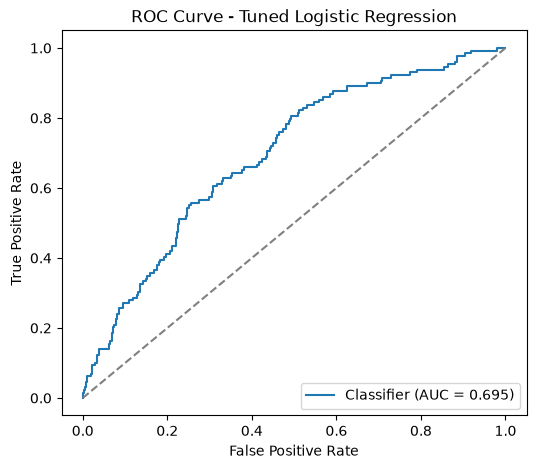

In [19]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lr_tuned)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_lr_tuned:.3f})"
)

# Plot the no-skill reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the tuned Logistic Regression model across different classification thresholds. The model achieved an ROC-AUC score of 0.695, representing an improvement over the untuned SMOTE-ENN Logistic Regression model (ROC-AUC = 0.661). This increase indicates that hyperparameter optimization enhanced the model's ability to distinguish between participants who developed coronary heart disease and those who did not.

Together with the observed improvements in recall and F1-score, the higher ROC-AUC score confirms that hyperparameter tuning improved the overall predictive performance of the Logistic Regression classifier while maintaining strong sensitivity to the minority class.

### **Conclusion**

Hyperparameter tuning successfully improved the predictive performance of the Logistic Regression classifier. Compared with the untuned SMOTE-ENN model, the tuned model achieved higher recall, F1-score, and ROC-AUC, indicating improved detection of participants who developed coronary heart disease. Although accuracy decreased slightly due to an increase in false positive predictions, the improvements in minority class detection and overall discriminative ability demonstrate that hyperparameter optimization produced a more effective Logistic Regression model for this imbalanced classification problem.

## **Random Forest Hyperparameter Tuning**

Hyperparameter tuning is performed to identify the optimal configuration of the Random Forest classifier. GridSearchCV systematically evaluates different combinations of tree-based hyperparameters using stratified five-fold cross-validation. A pipeline incorporating the SMOTE-ENN resampling technique is employed to address class imbalance during model optimization while preventing information leakage.

### **Hyperparameter Grid**

The hyperparameter search space includes different numbers of decision trees, maximum tree depths, minimum samples required for node splitting, and minimum samples required for leaf nodes. These parameters are optimized to improve the model's predictive performance while reducing the risk of overfitting.

In [20]:
# Define the Random Forest pipeline
rf_pipeline = Pipeline([
    ("resampler", SMOTEENN(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

# Define the hyperparameter grid
rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

# Initialize GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# Perform hyperparameter tuning
rf_grid.fit(X_train, y_train)

# Display the best results
print("Best Parameters:", rf_grid.best_params_)
print(f"Best Cross-Validation ROC-AUC: {rf_grid.best_score_:.3f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.700


**Best Hyperparameters**

GridSearchCV identified the optimal Random Forest configuration as 100 decision trees, a maximum tree depth of 5, a minimum of 5 samples required to split an internal node, and a minimum of 2 samples required at each leaf node. The optimized model achieved a mean cross-validation ROC-AUC score of 0.700, indicating good discriminative performance across the five validation folds while reducing the likelihood of overfitting.

### **Model Evaluation**

The optimized Random Forest pipeline is evaluated on the independent testing dataset to determine whether hyperparameter tuning improves predictive performance compared with the untuned SMOTE-ENN Random Forest model.

In [21]:
# Retrieve the best Random Forest pipeline
best_rf_model = rf_grid.best_estimator_

# Generate predicted class labels
y_pred_rf_tuned = best_rf_model.predict(X_test)

# Generate predicted probabilities
y_pred_proba_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The tuned Random Forest pipeline successfully generated predicted class labels and class probabilities for the testing dataset. These outputs are subsequently used to evaluate the effect of hyperparameter optimization on the model's predictive performance.

### **Performance Metrics**

The tuned Random Forest model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics are compared with those of the untuned SMOTE-ENN Random Forest model to determine whether hyperparameter tuning produced meaningful improvements in predictive performance.

In [22]:
# Calculate evaluation metrics
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)
roc_auc_rf_tuned = roc_auc_score(y_test, y_pred_proba_rf_tuned)

# Create a summary table
rf_tuned_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_rf_tuned, 3),
        round(precision_rf_tuned, 3),
        round(recall_rf_tuned, 3),
        round(f1_rf_tuned, 3),
        round(roc_auc_rf_tuned, 3)
    ]
})

rf_tuned_metrics

,Metric,Value
0,Accuracy,0.504
1,Precision,0.202
2,Recall,0.767
3,F1-score,0.320
4,ROC-AUC,0.668


The tuned Random Forest model achieved an accuracy of 0.504, precision of 0.202, recall of 0.767, F1-score of 0.320, and ROC-AUC of 0.668 on the testing dataset. Compared with the untuned SMOTE-ENN Random Forest model, hyperparameter tuning substantially improved recall and slightly increased the ROC-AUC score, indicating enhanced ability to identify participants who developed coronary heart disease.

However, these improvements were accompanied by reductions in accuracy and precision due to an increase in false positive predictions. Although the F1-score remained comparable to that of the untuned model, the higher recall suggests that the tuned Random Forest classifier became more sensitive to the minority class. Overall, hyperparameter tuning improved the model's ability to detect coronary heart disease cases while maintaining similar overall predictive balance.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes of the tuned Random Forest model by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives, thereby illustrating the effect of hyperparameter tuning on minority class detection.

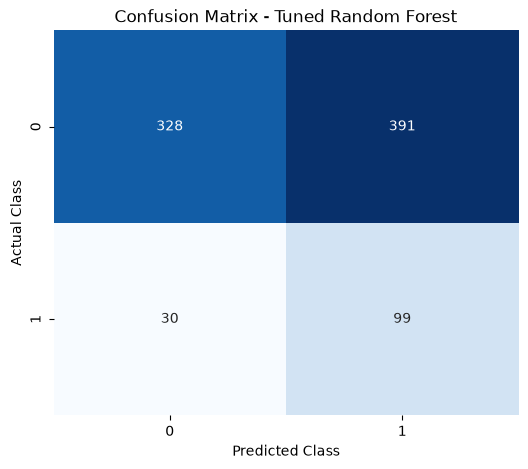

In [23]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf_tuned)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Tuned Random Forest")

# Display the plot
plt.show()


The confusion matrix demonstrates that hyperparameter tuning substantially improved the Random Forest model's ability to identify participants who developed coronary heart disease. Compared with the untuned SMOTE-ENN Random Forest model, the number of true positive predictions increased from 73 to 99, while false negatives decreased from 56 to 30, indicating a marked improvement in minority class detection.

These improvements were accompanied by a considerable increase in false positive predictions, which rose from 250 to 391, resulting in fewer correctly classified negative cases. Consequently, although the tuned model achieved substantially higher recall and improved overall discriminative ability, these gains were obtained at the expense of specificity and overall classification accuracy. Overall, hyperparameter tuning produced a Random Forest model that was considerably more sensitive to coronary heart disease cases.

### **Classification Report**

The classification report provides a detailed summary of the tuned Random Forest model's performance for each class by presenting precision, recall, F1-score, and support. These metrics provide additional insight into the effectiveness of hyperparameter optimization in improving minority class detection.

In [24]:
# Display the classification report
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.92      0.46      0.61       719
           1       0.20      0.77      0.32       129

    accuracy                           0.50       848
   macro avg       0.56      0.61      0.46       848
weighted avg       0.81      0.50      0.57       848




The classification report indicates that hyperparameter tuning substantially improved the Random Forest model's ability to identify participants who developed coronary heart disease. For the minority class, recall increased from 0.57 to 0.77, while the F1-score remained at 0.32, indicating that the improvement in sensitivity was accompanied by a corresponding reduction in precision.

The decrease in precision from 0.23 to 0.20 reflects the increase in false positive predictions observed in the confusion matrix. Nevertheless, the tuned model successfully identified a considerably larger proportion of participants who developed coronary heart disease, demonstrating enhanced sensitivity to the minority class. Overall, hyperparameter optimization produced a Random Forest classifier that prioritized minority class detection while maintaining comparable overall predictive balance.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is used to evaluate the overall discriminative ability of the tuned Random Forest model and is compared with that of the untuned SMOTE-ENN Random Forest model.

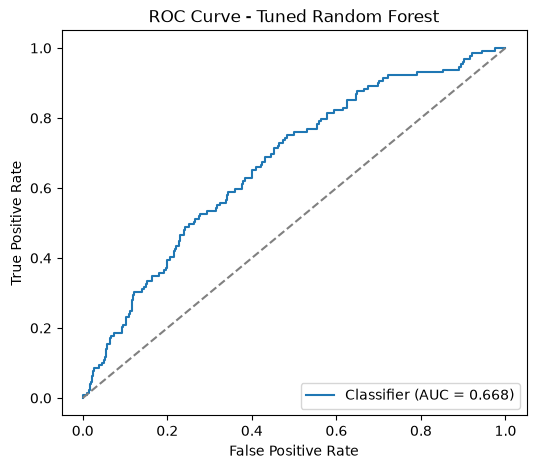

In [25]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf_tuned)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_rf_tuned:.3f})"
)

# Plot the no-skill reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend(loc="lower right")

# Display the plot
plt.show()


The ROC curve demonstrates the discriminative ability of the tuned Random Forest model across different classification thresholds. The model achieved an ROC-AUC score of 0.668, representing an improvement over the untuned SMOTE-ENN Random Forest model (ROC-AUC = 0.654). This increase indicates that hyperparameter optimization slightly enhanced the model's ability to distinguish between participants who developed coronary heart disease and those who did not.

Together with the substantial improvement in recall, the higher ROC-AUC score confirms that hyperparameter tuning increased the model's sensitivity to the minority class. Although these improvements were accompanied by reductions in accuracy and precision, the tuned Random Forest classifier demonstrated improved effectiveness in identifying coronary heart disease cases within the imbalanced dataset.

### **Conclusion**

Hyperparameter tuning improved the Random Forest classifier's ability to detect participants who developed coronary heart disease. Compared with the untuned SMOTE-ENN Random Forest model, the tuned model achieved higher recall and a modest improvement in ROC-AUC, indicating enhanced minority class detection and overall discriminative performance. These gains were accompanied by reductions in accuracy and precision due to an increase in false positive predictions.

Overall, hyperparameter optimization produced a Random Forest model that prioritized sensitivity to coronary heart disease cases, making it more suitable for applications where minimizing missed positive cases is considered more important than maximizing overall classification accuracy.

## **XGBoost Hyperparameter Tuning**

Hyperparameter tuning is performed to identify the optimal configuration of the XGBoost classifier. GridSearchCV systematically evaluates different combinations of boosting parameters using stratified five-fold cross-validation. A pipeline incorporating the SMOTE-ENN resampling technique is employed to address class imbalance during model optimization while preventing information leakage.

### **Hyperparameter Grid**

The hyperparameter search space includes different numbers of boosting rounds, tree depths, learning rates, subsampling ratios, and feature sampling ratios. These parameters are optimized to improve predictive performance while reducing the risk of overfitting.

In [26]:
# Define the XGBoost pipeline
xgb_pipeline = Pipeline([
    ("resampler", SMOTEENN(random_state=42)),
    ("model", xgb.XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# Define the hyperparameter grid
xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

# Initialize GridSearchCV
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# Perform hyperparameter tuning
xgb_grid.fit(X_train, y_train)

# Display the best results
print("Best Parameters:", xgb_grid.best_params_)
print(f"Best Cross-Validation ROC-AUC: {xgb_grid.best_score_:.3f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best Cross-Validation ROC-AUC: 0.704



GridSearchCV identified the optimal XGBoost configuration as 100 boosting rounds, a maximum tree depth of 3, a learning rate of 0.01, a subsampling ratio of 0.8, and a feature sampling ratio (`colsample_bytree`) of 1.0. The optimized model achieved a mean cross-validation ROC-AUC score of 0.704, indicating good discriminative performance across the five validation folds while promoting improved model generalization.

### **Model Evaluation**

The optimized XGBoost pipeline is evaluated on the independent testing dataset to determine whether hyperparameter tuning improves predictive performance compared with the untuned SMOTE-ENN XGBoost model.

In [27]:
# Retrieve the best XGBoost pipeline
best_xgb_model = xgb_grid.best_estimator_

# Generate predicted class labels
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Generate predicted probabilities
y_pred_proba_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The tuned XGBoost pipeline successfully generated predicted class labels and class probabilities for the testing dataset. These outputs are subsequently used to evaluate the effect of hyperparameter optimization on the model's predictive performance.

### **Performance Metrics**

The tuned XGBoost model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics are compared with those of the untuned SMOTE-ENN XGBoost model to determine whether hyperparameter tuning produced meaningful improvements in predictive performance.

In [28]:
# Calculate evaluation metrics
accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)
roc_auc_xgb_tuned = roc_auc_score(y_test, y_pred_proba_xgb_tuned)

# Create a summary table
xgb_tuned_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_xgb_tuned, 3),
        round(precision_xgb_tuned, 3),
        round(recall_xgb_tuned, 3),
        round(f1_xgb_tuned, 3),
        round(roc_auc_xgb_tuned, 3)
    ]
})

xgb_tuned_metrics

,Metric,Value
0,Accuracy,0.463
1,Precision,0.197
2,Recall,0.822
3,F1-score,0.318
4,ROC-AUC,0.667


The tuned XGBoost model achieved an accuracy of 0.463, precision of 0.197, recall of 0.822, F1-score of 0.318, and ROC-AUC of 0.667 on the testing dataset. Compared with the untuned SMOTE-ENN XGBoost model, hyperparameter tuning substantially improved recall, F1-score, and ROC-AUC, indicating enhanced ability to identify participants who developed coronary heart disease.

These improvements were accompanied by reductions in accuracy and precision due to an increase in false positive predictions. Nevertheless, the marked increase in recall demonstrates that the tuned XGBoost classifier became substantially more sensitive to the minority class. Overall, hyperparameter optimization improved the model's ability to detect coronary heart disease cases while enhancing its overall discriminative performance.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes of the tuned XGBoost model by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives, thereby illustrating the effect of hyperparameter tuning on minority class detection.

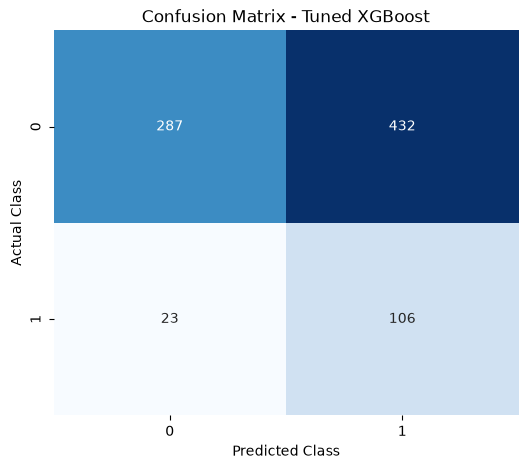

In [29]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb_tuned)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Tuned XGBoost")

# Display the plot
plt.show()


The confusion matrix demonstrates that hyperparameter tuning substantially improved the XGBoost model's ability to identify participants who developed coronary heart disease. Compared with the untuned SMOTE-ENN XGBoost model, the number of true positive predictions increased from 61 to 106, while false negatives decreased from 68 to 23, indicating a marked improvement in minority class detection.

These improvements were accompanied by a considerable increase in false positive predictions, which rose from 213 to 432, resulting in fewer correctly classified negative cases. Consequently, although the tuned model achieved substantially higher recall and improved overall discriminative ability, these gains were obtained at the expense of specificity and overall classification accuracy. Overall, hyperparameter tuning produced an XGBoost classifier that strongly prioritized the detection of coronary heart disease cases.

### **Classification Report**

The classification report provides a detailed summary of the tuned XGBoost model's performance for each class by presenting precision, recall, F1-score, and support. These metrics provide additional insight into the effectiveness of hyperparameter optimization in improving minority class detection.

In [ ]:
# Display the classification report
print(classification_report(y_test, y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.93      0.40      0.56       719
           1       0.20      0.82      0.32       129

    accuracy                           0.46       848
   macro avg       0.56      0.61      0.44       848
weighted avg       0.81      0.46      0.52       848




The classification report indicates that hyperparameter tuning substantially improved the XGBoost model's ability to identify participants who developed coronary heart disease. For the minority class, recall increased markedly from 0.47 to 0.82, while the F1-score improved from 0.30 to 0.32, demonstrating a better balance between precision and recall compared with the untuned SMOTE-ENN XGBoost model.

Although precision decreased slightly from 0.22 to 0.20 due to an increase in false positive predictions, the tuned model correctly identified a substantially greater proportion of coronary heart disease cases. Overall, these findings demonstrate that hyperparameter optimization significantly enhanced the sensitivity of the XGBoost classifier while improving its overall discriminative performance.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is used to evaluate the overall discriminative ability of the tuned XGBoost model and is compared with that of the untuned SMOTE-ENN XGBoost model.

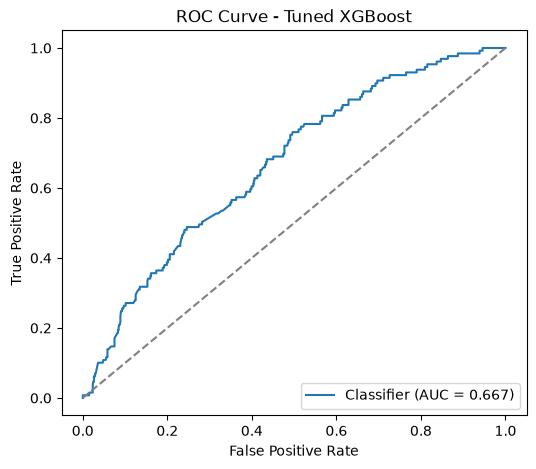

In [31]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_xgb_tuned)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_xgb_tuned:.3f})"
)

# Plot the no-skill reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the tuned XGBoost model across different classification thresholds. The model achieved an ROC-AUC score of 0.667, representing an improvement over the untuned SMOTE-ENN XGBoost model (ROC-AUC = 0.617). This increase indicates that hyperparameter optimization enhanced the model's ability to distinguish between participants who developed coronary heart disease and those who did not.

Together with the substantial improvements in recall and F1-score, the higher ROC-AUC score confirms that hyperparameter tuning enhanced the overall predictive performance of the XGBoost classifier while substantially improving its sensitivity to the minority class.

### **Conclusion**

Hyperparameter tuning successfully improved the predictive performance of the XGBoost classifier. Compared with the untuned SMOTE-ENN model, the tuned model achieved substantially higher recall, F1-score, and ROC-AUC, demonstrating improved detection of participants who developed coronary heart disease. Although these improvements were accompanied by reductions in accuracy and precision due to an increase in false positive predictions, the tuned XGBoost classifier provided considerably greater sensitivity to the minority class and enhanced overall discriminative performance.

## **Summary of Findings**

This notebook investigated the effect of hyperparameter tuning on the performance of the Logistic Regression, Random Forest, and XGBoost classifiers using GridSearchCV in conjunction with the SMOTE-ENN resampling technique. Hyperparameter optimization improved the ability of all three models to identify participants who developed coronary heart disease, as demonstrated by increases in recall and ROC-AUC compared with their respective untuned SMOTE-ENN models.

Among the tuned models, Logistic Regression achieved the highest ROC-AUC score (0.695) while maintaining strong recall (0.806), indicating the best overall balance between discrimination and minority class detection. Random Forest and XGBoost achieved even higher recall values (0.767 and 0.822, respectively), although these improvements were accompanied by larger reductions in accuracy and precision due to substantial increases in false positive predictions.

Overall, the findings demonstrate that hyperparameter tuning enhanced the predictive performance of all three classifiers, particularly with respect to minority class detection. The tuned models will be compared comprehensively with the baseline, class-weighted, SMOTE, and untuned SMOTE-ENN models in the subsequent model comparison notebook to identify the most suitable classifier for predicting ten-year coronary heart disease risk.

## **Model Persistence**

The optimized machine learning models are saved to the models directory using the `joblib` library. Persisting the tuned models ensures reproducibility, facilitates future comparative analyses, and enables their use during the final model selection and explainability stages of the study.

In [32]:
# Save the tuned Logistic Regression model
joblib.dump(
    best_lr_model,
    "../models/logistic_regression_tuned.pkl"
)

# Save the tuned Random Forest model
joblib.dump(
    best_rf_model,
    "../models/random_forest_tuned.pkl"
)

# Save the tuned XGBoost model
joblib.dump(
    best_xgb_model,
    "../models/xgboost_tuned.pkl"
)

print("Tuned models successfully saved to the models directory.")

Tuned models successfully saved to the models directory.


The tuned Logistic Regression, Random Forest, and XGBoost models were successfully saved to the models directory. These optimized models will be used in the subsequent model comparison and explainability analyses to determine the most suitable classifier for predicting ten-year coronary heart disease risk.

### **Final Evaluation of Tuned Models**

The best Logistic Regression, Random Forest, and XGBoost pipelines identified through GridSearchCV are evaluated together on the independent testing dataset. This final evaluation provides a concise summary of their predictive performance before the tuned models are saved and compared comprehensively in the subsequent model comparison notebook.

In [33]:
# Define a reusable evaluation function
def evaluate_model(name, model, X_test, y_test):
    # Generate predicted class labels
    y_pred = model.predict(X_test)

    # Generate predicted probabilities for the positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Return the evaluation metrics
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    }


# Evaluate the tuned models
tuned_results = [
    evaluate_model(
        "Tuned Logistic Regression",
        best_lr_model,
        X_test,
        y_test
    ),
    evaluate_model(
        "Tuned Random Forest",
        best_rf_model,
        X_test,
        y_test
    ),
    evaluate_model(
        "Tuned XGBoost",
        best_xgb_model,
        X_test,
        y_test
    )
]

# Create a summary table
tuned_comparison = pd.DataFrame(tuned_results)

# Round the metric values
tuned_comparison.iloc[:, 1:] = tuned_comparison.iloc[:, 1:].round(3)

tuned_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Logistic Regression,0.546,0.224,0.806,0.351,0.695
1,Tuned Random Forest,0.504,0.202,0.767,0.320,0.668
2,Tuned XGBoost,0.463,0.197,0.822,0.318,0.667



The final comparison of the tuned models shows that Logistic Regression achieved the highest accuracy (0.546), precision (0.224), F1-score (0.351), and ROC-AUC (0.695). This indicates that it provided the strongest overall balance between minority class detection and discriminative performance among the tuned classifiers.

XGBoost achieved the highest recall (0.822), followed by Logistic Regression (0.806) and Random Forest (0.767). This means that XGBoost identified the largest proportion of participants who developed coronary heart disease. However, it also recorded the lowest accuracy and precision, indicating a greater number of false positive predictions.

Random Forest produced intermediate performance, with a recall of 0.767 and an ROC-AUC of 0.668. Overall, Logistic Regression demonstrated the best balanced performance, while XGBoost was the most sensitive model for detecting positive coronary heart disease cases. A final model should therefore be selected according to whether the study prioritizes overall discrimination and predictive balance or the maximum detection of positive cases.

**Next Phase:** Model Comparison